In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [63]:
df = pd.read_csv('Unemployment in India.csv')
print("Dataset loaded successfully!")
df.head()


Dataset loaded successfully!


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [65]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [66]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [67]:
df.columns = df.columns.str.strip()

In [68]:
df = df.dropna( how='all')
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

In [69]:
df['Date'] = pd.to_datetime(df['Date'].str.strip(), format='%d-%m-%Y')
df['Date']

0     2019-05-31
1     2019-06-30
2     2019-07-31
3     2019-08-31
4     2019-09-30
         ...    
749   2020-02-29
750   2020-03-31
751   2020-04-30
752   2020-05-31
753   2020-06-30
Name: Date, Length: 740, dtype: datetime64[ns]

In [70]:
df['Date'].dt.month_name()

0            May
1           June
2           July
3         August
4      September
         ...    
749     February
750        March
751        April
752          May
753         June
Name: Date, Length: 740, dtype: object

In [71]:
df.dtypes

Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
dtype: object

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


In [73]:
df.to_csv('Cleaned_Unemployment_in_India.csv', index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


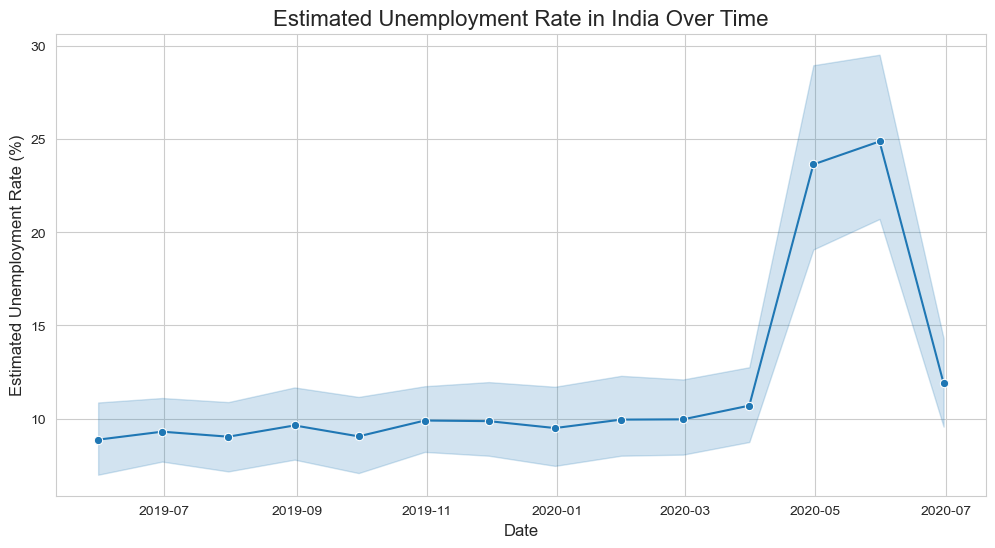

In [88]:
sns.set_style('whitegrid')
plt.figure(figsize = (12,6))
sns.lineplot(data = df, x = 'Date', y = 'Estimated Unemployment Rate (%)', marker='o')
plt.title('Estimated Unemployment Rate in India Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Estimated Unemployment Rate (%)', fontsize=12)

plt.savefig('unemployment_trend.png')

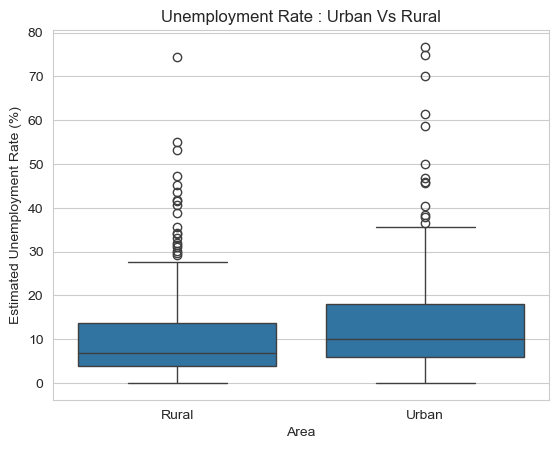

In [89]:
plt.Figure(figsize=(12,6))
sns.boxplot(data=df, x = 'Area', y = 'Estimated Unemployment Rate (%)')
plt.title('Unemployment Rate : Urban Vs Rural')
plt.savefig('urban_vs_rural.png')

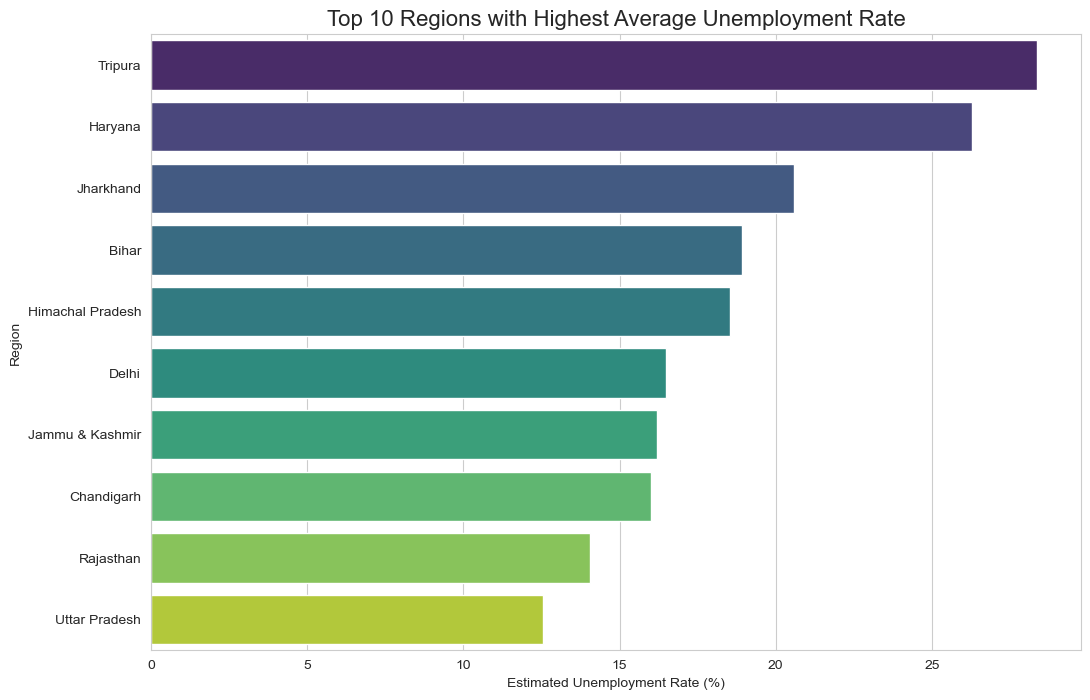

<Figure size 640x480 with 0 Axes>

In [90]:
avg_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12,8))
sns.barplot(data=avg_unemployment.head(10), x='Estimated Unemployment Rate (%)', y='Region', palette='viridis')
plt.title('Top 10 Regions with Highest Average Unemployment Rate', fontsize=16)
plt.show()
plt.savefig('top10_regions_unemployment.png')

In [77]:
df['year'] = df['Date'].dt.year
df['month_name'] = df['Date'].dt.month_name()
df['month_year'] = df['Date'].dt.to_period('M')

In [78]:
lockdown_mask = (df['Date'] >= '2020-03-01') & (df['Date'] <= '2020-06-30')
pre_lockdown_mask = df['Date'] < '2020-03-01'

df_covid = df.copy()
df_covid.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,year,month_name,month_year
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,May,2019-05
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,June,2019-06
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,July,2019-07
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,August,2019-08
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,September,2019-09


In [79]:
df_covid['Period'] = 'Post_lockdown'
df_covid.loc[pre_lockdown_mask, 'Period'] = 'Pre_lockdown'
df_covid.loc[lockdown_mask, 'Period'] = 'Lockdown'
df_covid['Period'].value_counts()

Period
Pre_lockdown    536
Lockdown        204
Name: count, dtype: int64

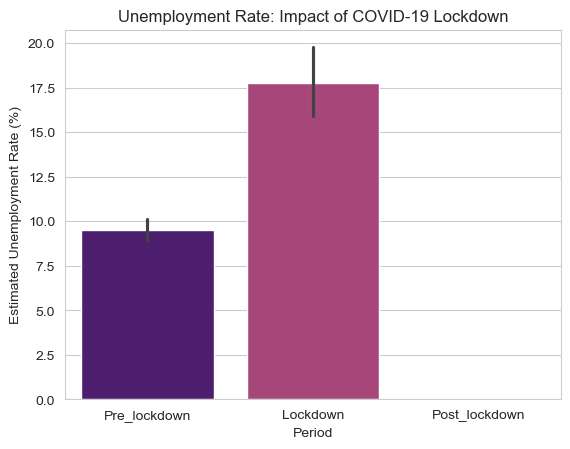

In [91]:
plt.Figure(figsize=(12,6))
sns.barplot(data = df_covid, x = 'Period', y = 'Estimated Unemployment Rate (%)', order=['Pre_lockdown', 'Lockdown', 'Post_lockdown'], palette='magma')
plt.title('Unemployment Rate: Impact of COVID-19 Lockdown')
plt.savefig('covid_lockdown_impact.png')

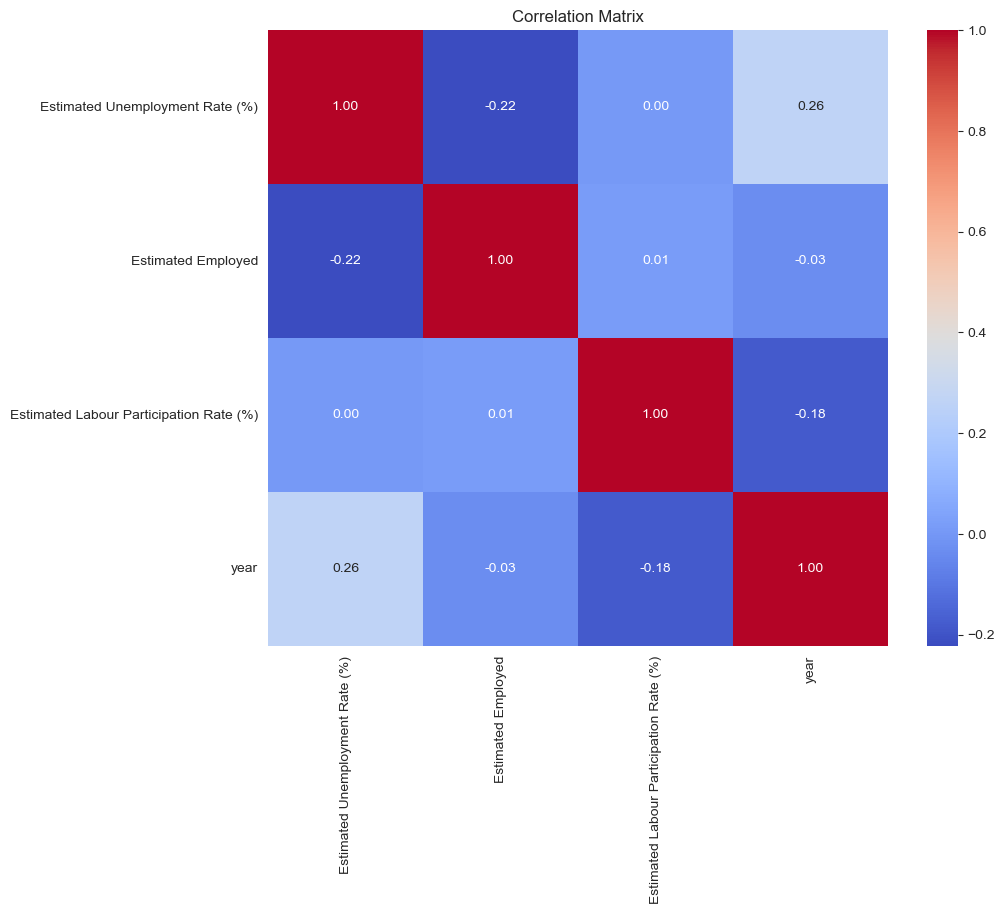

In [99]:
plt.figure(figsize=(10,8))
num_df = df.select_dtypes(include=[np.number])
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix')
plt.savefig('correlation_heatmap.png')

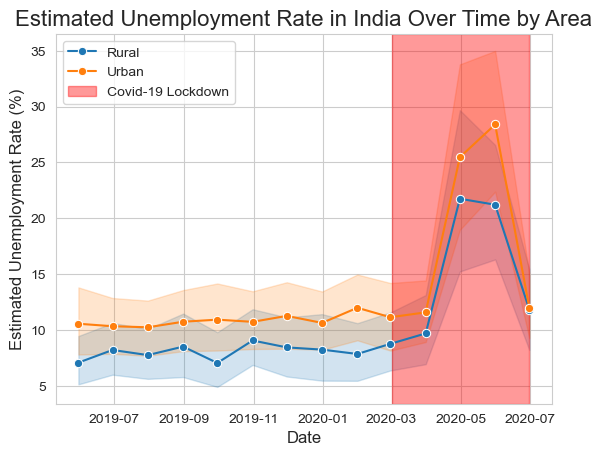

In [93]:
plt.Figure(figsize=(14,8))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', hue='Area', marker='o')
plt.axvspan('2020-03-01', '2020-06-30', color = 'red', alpha = 0.4, label = 'Covid-19 Lockdown')
plt.title('Estimated Unemployment Rate in India Over Time by Area', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Estimated Unemployment Rate (%)', fontsize=12)
plt.legend()
plt.savefig('unemployment_trend_by_area.png')


In [83]:
covid_summary = df_covid.groupby('Period')['Estimated Unemployment Rate (%)'].agg('mean','max','std').reset_index()
print(covid_summary)


         Period  Estimated Unemployment Rate (%)
0      Lockdown                        17.774363
1  Pre_lockdown                         9.509534


In [84]:
print('min date:', df['Date'].min())
print('max date:', df['Date'].max())


min date: 2019-05-31 00:00:00
max date: 2020-06-30 00:00:00


In [85]:
df_monthly = df.groupby(df['Date'].dt.month)['Estimated Unemployment Rate (%)'].mean().reset_index()
df_monthly.columns = ['Month', 'Avg Unemployment Rate (%)']
df_monthly.head()

,Month,Avg Unemployment Rate (%)
0,1,9.950755
1,2,9.964717
2,3,10.700577
3,4,23.641569
4,5,16.646190


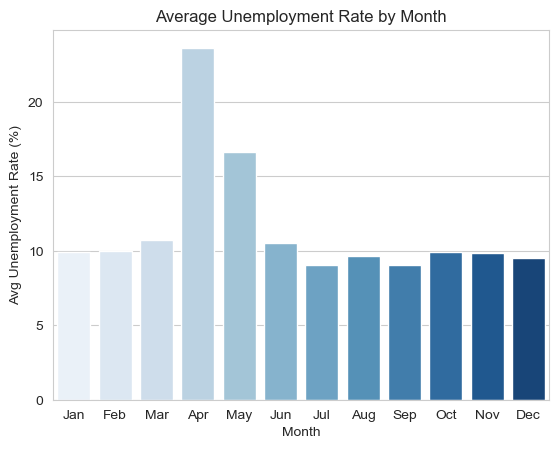

In [97]:
plt.Figure(figsize=(12,6))
sns.barplot(data=df_monthly, x='Month', y='Avg Unemployment Rate (%)', palette='Blues')
plt.title('Average Unemployment Rate by Month')
plt.xticks(ticks = range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.savefig('average_unemployment_by_month.png')

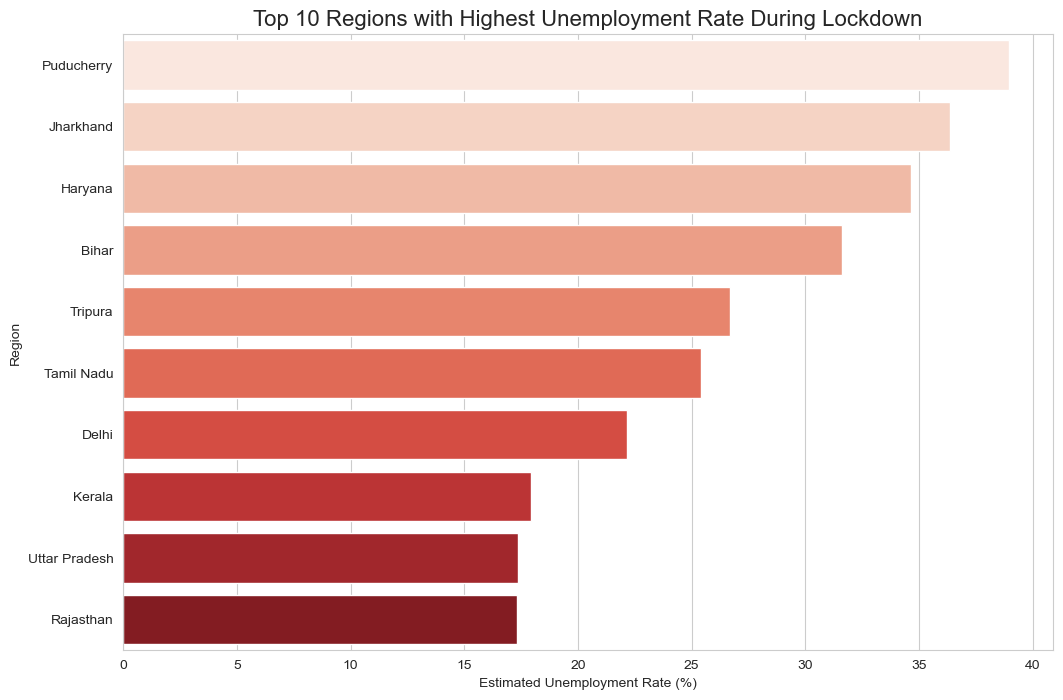

In [94]:
df_lockdown_states = df_covid[df_covid['Period'] == 'Lockdown'].groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10).reset_index()   
plt.figure(figsize=(12,8))
sns.barplot(data=df_lockdown_states, x='Estimated Unemployment Rate (%)', y='Region', palette='Reds')
plt.title('Top 10 Regions with Highest Unemployment Rate During Lockdown', fontsize=16)
plt.savefig('lockdown_top10_regions.png')